## GRU Model Implementation

In [2]:
# Importing Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [3]:
# Downloading data

tickers = ['KO', 'PEP']

prices = yf.download(
    tickers,
    start='2005-01-01',
    auto_adjust=False
)['Adj Close']

prices.columns = ['KO', 'PEP']
prices = prices.dropna()

print(prices.head())
print(prices.tail())
print(prices.shape)

[*********************100%***********************]  2 of 2 completed

                   KO        PEP
Date                            
2005-01-03  10.941302  28.442074
2005-01-04  10.788531  28.239466
2005-01-05  10.738492  28.272310
2005-01-06  10.828044  28.474928
2005-01-07  10.841216  28.721344
                   KO         PEP
Date                             
2026-04-17  75.739998  157.669998
2026-04-20  75.480003  156.990005
2026-04-21  74.699997  154.919998
2026-04-22  74.629997  153.789993
2026-04-23  76.279999  155.699997
(5360, 2)


In [4]:
# Trimming downloaded data to keep recent 10 years for maintaining recency 

prices = prices.loc['2015-01-01':].copy()

print(prices.head())
print(prices.tail())
print(prices.shape)

                   KO        PEP
Date                            
2015-01-02  29.580011  67.283470
2015-01-05  29.580011  66.777618
2015-01-06  29.804628  66.271782
2015-01-07  30.176670  68.209641
2015-01-08  30.541677  69.449295
                   KO         PEP
Date                             
2026-04-17  75.739998  157.669998
2026-04-20  75.480003  156.990005
2026-04-21  74.699997  154.919998
2026-04-22  74.629997  153.789993
2026-04-23  76.279999  155.699997
(2843, 2)


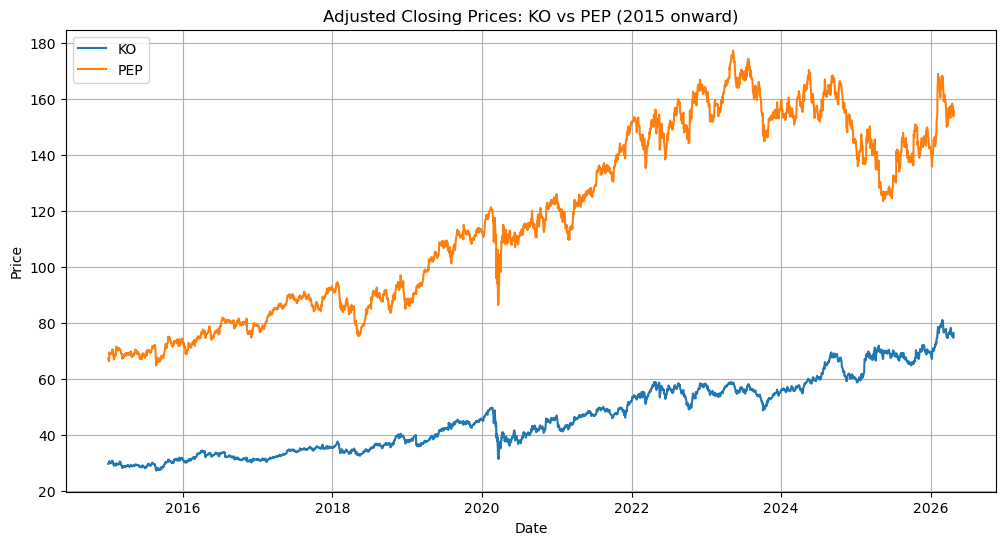

In [5]:
# Plot historical prices

plt.figure(figsize=(12, 6))
plt.plot(prices.index, prices['KO'], label='KO')
plt.plot(prices.index, prices['PEP'], label='PEP')
plt.title('Adjusted Closing Prices: KO vs PEP (2015 onward)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

In [6]:
# Converting to log returns

log_returns = np.log(prices / prices.shift(1)).dropna()

print(log_returns.head())
print(log_returns.tail())
print(log_returns.shape)

                  KO       PEP
Date                          
2015-01-05  0.000000 -0.007547
2015-01-06  0.007565 -0.007604
2015-01-07  0.012405  0.028822
2015-01-08  0.012023  0.018011
2015-01-09 -0.011093 -0.006794
                  KO       PEP
Date                          
2026-04-17  0.007421 -0.004493
2026-04-20 -0.003439 -0.004322
2026-04-21 -0.010388 -0.013273
2026-04-22 -0.000938 -0.007321
2026-04-23  0.021868  0.012343
(2842, 2)


In [7]:
# Train-test split

train_size = int(len(log_returns) * 0.8)

train_returns = log_returns.iloc[:train_size]
test_returns = log_returns.iloc[train_size:]

print("Train shape:", train_returns.shape)
print("Test shape:", test_returns.shape)

Train shape: (2273, 2)
Test shape: (569, 2)


In [8]:
# Scaling log returns

scaler = MinMaxScaler(feature_range=(0, 1))

train_scaled = scaler.fit_transform(train_returns)
test_scaled = scaler.transform(test_returns)

In [9]:
# creating sequences

def create_sequences(data, lookback=30):
    X, y = [], []
    
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i])
        y.append(data[i])
    
    return np.array(X), np.array(y)

lookback = 30

X_train, y_train = create_sequences(train_scaled, lookback)
X_test, y_test = create_sequences(test_scaled, lookback)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (2243, 30, 2)
y_train shape: (2243, 2)
X_test shape: (539, 30, 2)
y_test shape: (539, 2)


In [10]:
# Building GRU model

model = Sequential([
    GRU(64, return_sequences=True, input_shape=(lookback, 2)),
    Dropout(0.2),
    
    GRU(64, return_sequences=False),
    Dropout(0.2),
    
    Dense(32, activation='relu'),
    Dense(2)
])

model.compile(optimizer='adam', loss='mse')

model.summary()

C:\Users\engr_\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ gru (GRU)                            │ (None, 30, 64)              │          13,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 30, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_1 (GRU)                          │ (None, 64)                  │          24,960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 2)                   │              66 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 40,162 (156.88 KB)

 Trainable params: 40,162 (156.88 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Trainning Model

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 9s 44ms/step - loss: 0.0280 - val_loss: 0.0036
Epoch 2/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 0.0068 - val_loss: 0.0037
Epoch 3/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 0.0063 - val_loss: 0.0036
Epoch 4/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0059 - val_loss: 0.0033
Epoch 5/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0054 - val_loss: 0.0038
Epoch 6/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 0.0053 - val_loss: 0.0035
Epoch 7/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - loss: 0.0051 - val_loss: 0.0033
Epoch 8/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.0049 - val_loss: 0.0033
Epoch 9/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.0050 - val_loss: 0.0032
Epoch 10/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0047 - val_loss: 0.0045
Epoch 11/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0045 - val_loss: 0.0038
Epoch 12/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step

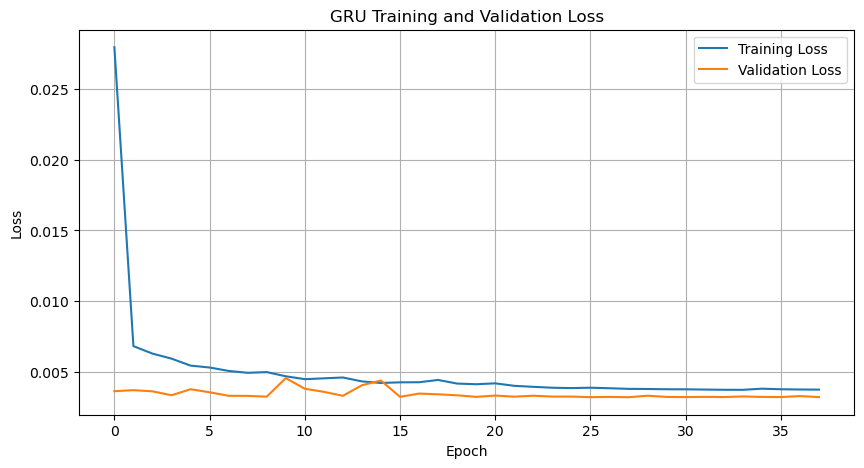

In [12]:
# Plotting Training History

plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('GRU Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [13]:
# Predicing test log returns

y_pred_scaled = model.predict(X_test)

y_test_log = scaler.inverse_transform(y_test)
y_pred_log = scaler.inverse_transform(y_pred_scaled)

pred_returns_df = pd.DataFrame(
    y_pred_log,
    columns=['KO_Pred_LogRet', 'PEP_Pred_LogRet'],
    index=test_returns.index[lookback:]
)

actual_returns_df = pd.DataFrame(
    y_test_log,
    columns=['KO_Actual_LogRet', 'PEP_Actual_LogRet'],
    index=test_returns.index[lookback:]
)

returns_results = pd.concat([actual_returns_df, pred_returns_df], axis=1)

print(returns_results.head())

17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step
            KO_Actual_LogRet  PEP_Actual_LogRet  KO_Pred_LogRet  \
Date                                                              
2024-02-29         -0.006311          -0.002567        0.000429   
2024-03-01         -0.008197          -0.004546        0.000396   
2024-03-04          0.004693           0.004728        0.000351   
2024-03-05         -0.004861          -0.020342        0.000278   
2024-03-06          0.000504           0.005907        0.000455   

            PEP_Pred_LogRet  
Date                         
2024-02-29         0.000400  
2024-03-01         0.000341  
2024-03-04         0.000264  
2024-03-05         0.000167  
2024-03-06         0.000416  


In [14]:
# Converting test log returns to prices

test_price_index = test_returns.index[lookback:]

ko_actual_prices = []
ko_pred_prices = []
pep_actual_prices = []
pep_pred_prices = []

for date in test_price_index:
    prev_price_row = prices.shift(1).loc[date]

    ko_prev_price = prev_price_row['KO']
    pep_prev_price = prev_price_row['PEP']

    ko_actual_price = ko_prev_price * np.exp(returns_results.loc[date, 'KO_Actual_LogRet'])
    ko_pred_price = ko_prev_price * np.exp(returns_results.loc[date, 'KO_Pred_LogRet'])

    pep_actual_price = pep_prev_price * np.exp(returns_results.loc[date, 'PEP_Actual_LogRet'])
    pep_pred_price = pep_prev_price * np.exp(returns_results.loc[date, 'PEP_Pred_LogRet'])

    ko_actual_prices.append(ko_actual_price)
    ko_pred_prices.append(ko_pred_price)
    pep_actual_prices.append(pep_actual_price)
    pep_pred_prices.append(pep_pred_price)

price_results = pd.DataFrame({
    'KO_Actual': ko_actual_prices,
    'KO_Predicted': ko_pred_prices,
    'PEP_Actual': pep_actual_prices,
    'PEP_Predicted': pep_pred_prices
}, index=test_price_index)

print(price_results.head())

            KO_Actual  KO_Predicted  PEP_Actual  PEP_Predicted
Date                                                          
2024-02-29  56.185818     56.565828  153.854477     154.311704
2024-03-01  55.727123     56.208055  153.156586     153.906914
2024-03-04  55.989243     55.746694  153.882385     153.196990
2024-03-05  55.717762     56.004801  150.783707     153.908049
2024-03-06  55.745846     55.743141  151.677032     150.846493


In [15]:
# Evaluation metrics

def evaluate_forecast(actual, predicted, stock_name):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100

    print(f"{stock_name} Performance:")
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"MAPE : {mape:.2f}%")
    print()

evaluate_forecast(price_results['KO_Actual'], price_results['KO_Predicted'], 'KO')
evaluate_forecast(price_results['PEP_Actual'], price_results['PEP_Predicted'], 'PEP')

KO Performance:
MAE  : 0.5048
RMSE : 0.6697
MAPE : 0.75%

PEP Performance:
MAE  : 1.3878
RMSE : 1.8777
MAPE : 0.94%



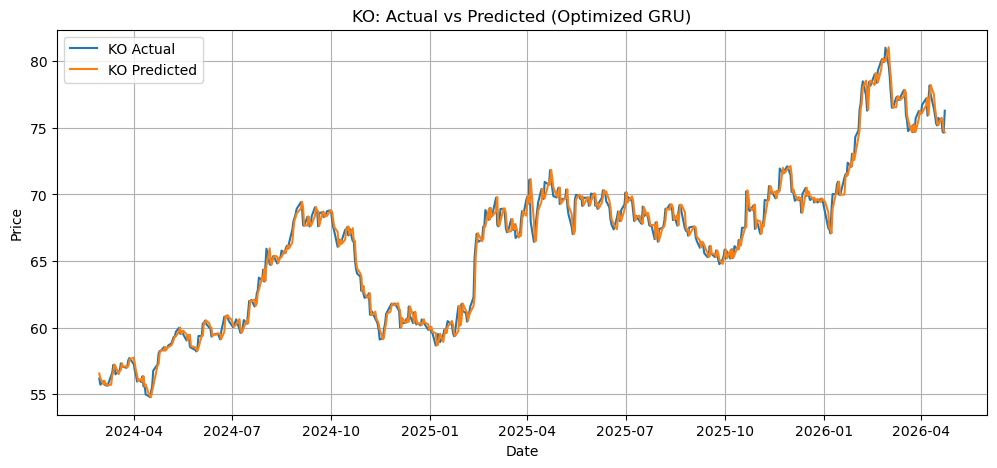

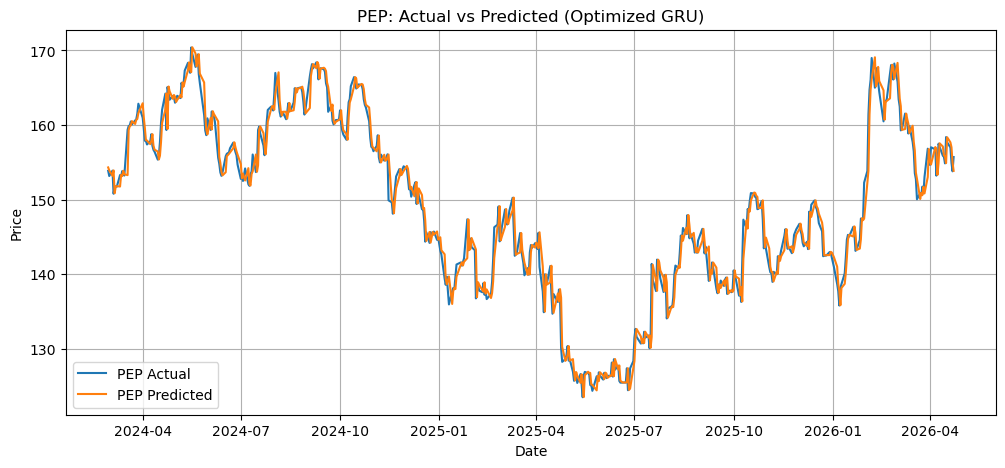

In [16]:
# Plotting actual vs predicted prices

plt.figure(figsize=(12, 5))
plt.plot(price_results.index, price_results['KO_Actual'], label='KO Actual')
plt.plot(price_results.index, price_results['KO_Predicted'], label='KO Predicted')
plt.title('KO: Actual vs Predicted (Optimized GRU)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(price_results.index, price_results['PEP_Actual'], label='PEP Actual')
plt.plot(price_results.index, price_results['PEP_Predicted'], label='PEP Predicted')
plt.title('PEP: Actual vs Predicted (Optimized GRU)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

In [17]:
# Forecasting next 10 days

forecast_horizon = 10

full_scaled = scaler.transform(log_returns)
last_window = full_scaled[-lookback:].copy()

future_log_returns_scaled = []

for _ in range(forecast_horizon):
    x_input = last_window.reshape(1, lookback, 2)
    next_pred_scaled = model.predict(x_input, verbose=0)[0]
    
    future_log_returns_scaled.append(next_pred_scaled)
    
    last_window = np.vstack([last_window[1:], next_pred_scaled])

future_log_returns_scaled = np.array(future_log_returns_scaled)
future_log_returns = scaler.inverse_transform(future_log_returns_scaled)

future_returns_df = pd.DataFrame(
    future_log_returns,
    columns=['KO_LogRet_Forecast', 'PEP_LogRet_Forecast']
)

print(future_returns_df)

   KO_LogRet_Forecast  PEP_LogRet_Forecast
0            0.000380             0.000333
1            0.000358             0.000333
2            0.000352             0.000336
3            0.000352             0.000336
4            0.000356             0.000334
5            0.000362             0.000334
6            0.000367             0.000332
7            0.000372             0.000331
8            0.000374             0.000330
9            0.000376             0.000328


In [18]:
# Coverting future log returns to future prices

last_ko_price = prices['KO'].iloc[-1]
last_pep_price = prices['PEP'].iloc[-1]

ko_future_prices = []
pep_future_prices = []

ko_price = last_ko_price
pep_price = last_pep_price

for i in range(forecast_horizon):
    ko_price = ko_price * np.exp(future_returns_df.loc[i, 'KO_LogRet_Forecast'])
    pep_price = pep_price * np.exp(future_returns_df.loc[i, 'PEP_LogRet_Forecast'])

    ko_future_prices.append(ko_price)
    pep_future_prices.append(pep_price)

forecast_df = pd.DataFrame({
    'KO_Forecast': ko_future_prices,
    'PEP_Forecast': pep_future_prices
})

future_dates = pd.bdate_range(
    start=prices.index[-1] + pd.Timedelta(days=1),
    periods=forecast_horizon
)

forecast_df.index = future_dates

print(forecast_df)

            KO_Forecast  PEP_Forecast
2026-04-24    76.309015    155.751912
2026-04-27    76.336369    155.803770
2026-04-28    76.363269    155.856090
2026-04-29    76.390178    155.908392
2026-04-30    76.417379    155.960488
2026-05-01    76.445054    156.012508
2026-05-04    76.473122    156.064341
2026-05-05    76.501547    156.116079
2026-05-06    76.530173    156.167537
2026-05-07    76.558957    156.218808


In [19]:
# Checking continuity

print("Last actual KO:", prices['KO'].iloc[-1])
print("First forecast KO:", forecast_df['KO_Forecast'].iloc[0])

print("Last actual PEP:", prices['PEP'].iloc[-1])
print("First forecast PEP:", forecast_df['PEP_Forecast'].iloc[0])

Last actual KO: 76.27999877929688
First forecast KO: 76.30901545001325
Last actual PEP: 155.6999969482422
First forecast PEP: 155.75191174643805


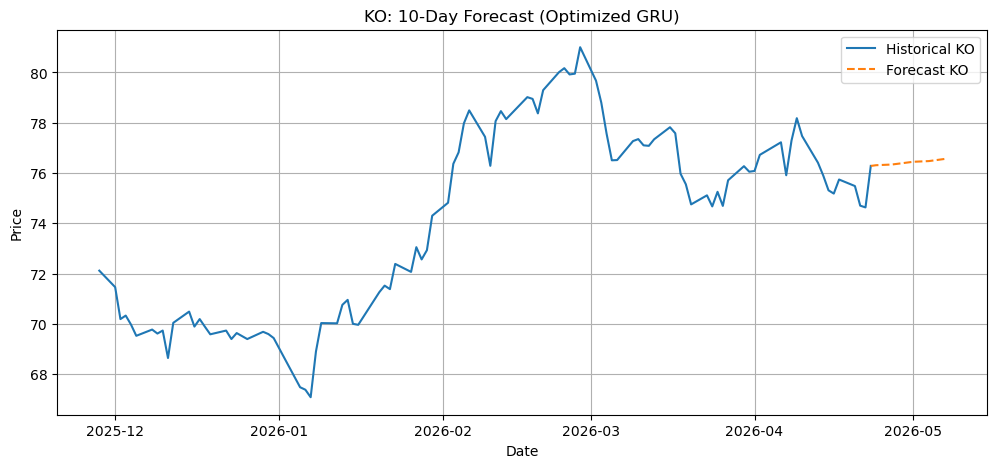

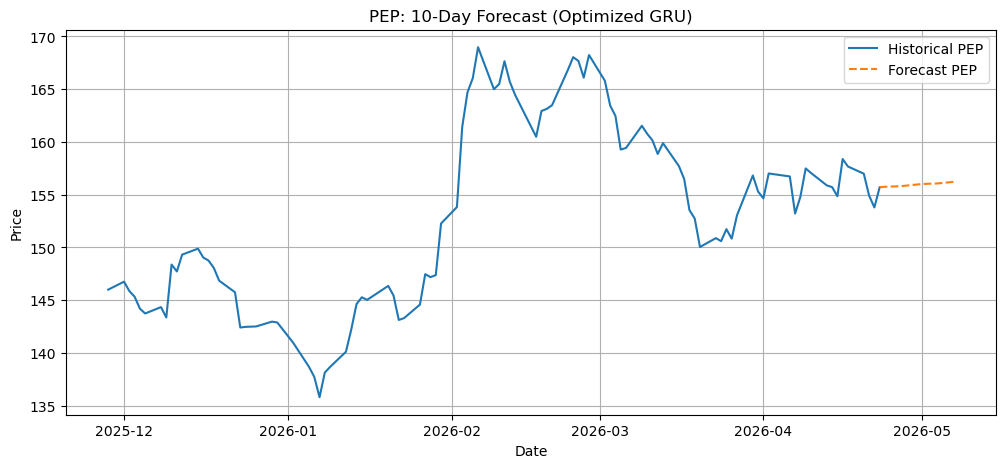

In [20]:
# Plotting forecast

plt.figure(figsize=(12, 5))
plt.plot(prices.index[-100:], prices['KO'].iloc[-100:], label='Historical KO')

ko_connected_dates = [prices.index[-1]] + list(forecast_df.index)
ko_connected_values = [prices['KO'].iloc[-1]] + list(forecast_df['KO_Forecast'])

plt.plot(ko_connected_dates, ko_connected_values, linestyle='--', label='Forecast KO')
plt.title('KO: 10-Day Forecast (Optimized GRU)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(prices.index[-100:], prices['PEP'].iloc[-100:], label='Historical PEP')

pep_connected_dates = [prices.index[-1]] + list(forecast_df.index)
pep_connected_values = [prices['PEP'].iloc[-1]] + list(forecast_df['PEP_Forecast'])

plt.plot(pep_connected_dates, pep_connected_values, linestyle='--', label='Forecast PEP')
plt.title('PEP: 10-Day Forecast (Optimized GRU)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

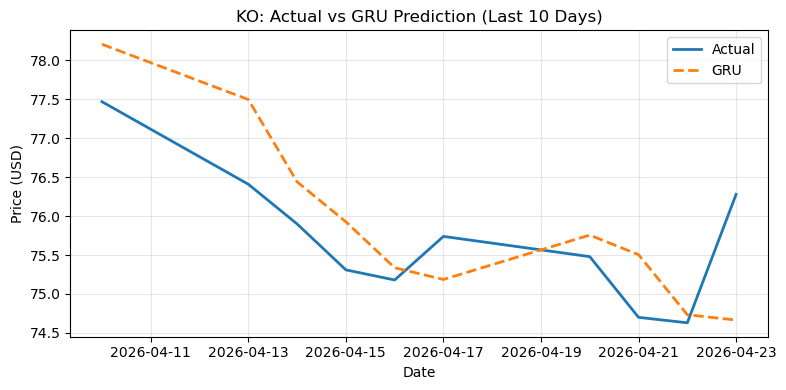

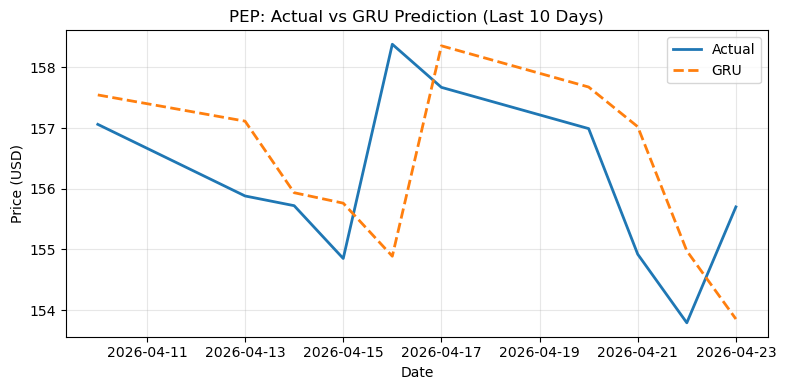

In [41]:
import matplotlib.pyplot as plt

# Select last 10 days
window = 10
gru_subset = price_results.tail(window)

# KO plot
plt.figure(figsize=(8,4))
plt.plot(
    gru_subset.index,
    gru_subset['KO_Actual'],
    label='Actual',
    linewidth=2
)
plt.plot(
    gru_subset.index,
    gru_subset['KO_Predicted'],
    label='GRU',
    linestyle='--',
    linewidth=2
)

plt.title('KO: Actual vs GRU Prediction (Last 10 Days)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# PEP plot
plt.figure(figsize=(8,4))
plt.plot(
    gru_subset.index,
    gru_subset['PEP_Actual'],
    label='Actual',
    linewidth=2
)
plt.plot(
    gru_subset.index,
    gru_subset['PEP_Predicted'],
    label='GRU',
    linestyle='--',
    linewidth=2
)

plt.title('PEP: Actual vs GRU Prediction (Last 10 Days)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

END